# Cross-validation

### Which flavour to use when, and why the fold boundary is where leaks happen

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why one train/test split tells you almost nothing, how KFold, StratifiedKFold, GroupKFold and TimeSeriesSplit differ, when LeaveOneOut is a waste of electricity, what repeated CV buys, and how much a score inflates when preprocessing happens outside the fold |
| **You should already know** | [Train, validation, test](../02-train-validation-test/), [overfitting and underfitting](../03-overfitting-and-underfitting/) |
| **Datasets** | UCI Dry Bean, UCI Bike Sharing, Breast Cancer Wisconsin, plus one matrix of pure noise |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [01-05 Metrics for classification](../05-classification-metrics/) |

---

## 1. The idea

You hold out 20% of your rows, train on the rest, and score on the held-out
part. You get 0.91. What is that number?

It is one draw from a distribution. Had you shuffled with a different seed you
would have got a different 20%, a different model, and a different score. The
0.91 is a sample of size one, and nobody reports a sample of size one as if it
were a measurement.

Cross-validation fixes this by rotating the held-out part. Cut the data into $k$
folds, hold out each fold in turn, and average the $k$ scores. Every row gets
tested exactly once, and you end up with $k$ numbers instead of one, so you can
see how much the answer moves.

That is the whole idea. The rest of this notebook is about the ways the fold
boundary can be drawn wrong.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

### One split is a sample of size one

I take a stratified 900-row slice of the Dry Bean data so a single split is
small enough to wobble visibly, fit the same decision tree 200 times on 200
different random splits, and look at the spread of the scores. Then I do the
same thing to 5-fold cross-validation: 60 runs, each with a different shuffle,
each producing one averaged number.

single split : mean 0.8792  sd 0.0226  range 0.1000
5-fold mean  : mean 0.8805  sd 0.0074  range 0.0333

the single-split answer is 3.0x more variable than the cross-validated one


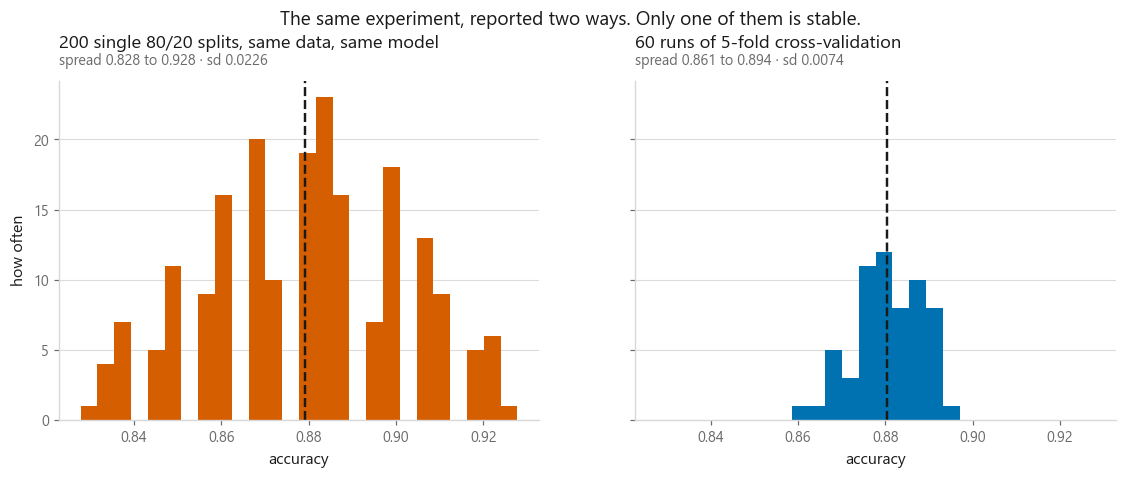

In [2]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier

X_bean, y_bean = datasets.dry_bean()

# A small slice keeps the demonstration honest: the wobble I want to show is
# real at every size, it is just easier to see when the test fold is 180 rows.
X_small, _, y_small, _ = train_test_split(
    X_bean, y_bean, train_size=900, stratify=y_bean, random_state=SEED)
X_small = X_small.to_numpy()
y_small = y_small.to_numpy()

tree = DecisionTreeClassifier(random_state=SEED)

single_split = []
for seed in range(200):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_small, y_small, test_size=0.2, stratify=y_small, random_state=seed)
    single_split.append(tree.fit(X_tr, y_tr).score(X_te, y_te))
single_split = np.array(single_split)

cv_means = np.array([
    cross_val_score(tree, X_small, y_small,
                    cv=StratifiedKFold(5, shuffle=True, random_state=seed)).mean()
    for seed in range(60)
])

bins = np.histogram_bin_edges(np.r_[single_split, cv_means], bins=26)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.0), sharex=True, sharey=True)

axes[0].hist(single_split, bins=bins, color=style.HIGHLIGHT)
axes[0].axvline(single_split.mean(), color=style.INK, lw=1.6, ls="--")
style.title(axes[0], "200 single 80/20 splits, same data, same model",
            f"spread {single_split.min():.3f} to {single_split.max():.3f}"
            f" · sd {single_split.std():.4f}")

axes[1].hist(cv_means, bins=bins, color=style.PALETTE[0])
axes[1].axvline(cv_means.mean(), color=style.INK, lw=1.6, ls="--")
style.title(axes[1], "60 runs of 5-fold cross-validation",
            f"spread {cv_means.min():.3f} to {cv_means.max():.3f}"
            f" · sd {cv_means.std():.4f}")

for ax in axes:
    ax.set_xlabel("accuracy")
axes[0].set_ylabel("how often")
fig.suptitle("The same experiment, reported two ways. Only one of them is stable.",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-one-split-is-one-sample.png")

print(f"single split : mean {single_split.mean():.4f}  sd {single_split.std():.4f}  "
      f"range {single_split.max() - single_split.min():.4f}")
print(f"5-fold mean  : mean {cv_means.mean():.4f}  sd {cv_means.std():.4f}  "
      f"range {cv_means.max() - cv_means.min():.4f}")
print(f"\nthe single-split answer is {single_split.std() / cv_means.std():.1f}x "
      f"more variable than the cross-validated one")

Both histograms sit over roughly the same centre, so a single split is not
*biased* here — it is noisy. If I had run one split and reported it, the number
I published would have depended on a seed. Two people doing the same honest work
on the same data would disagree, and neither would be wrong.

Averaging over folds shrinks that noise. It does not remove it, which is why the
right-hand histogram still has width, and why the repeated-CV section below
exists.

## 2. The mechanism

Split the $n$ rows into $k$ disjoint folds $F_1, \dots, F_k$ of near-equal size.
For each $i$, fit on everything except $F_i$ and score on $F_i$, giving $s_i$.
Report

$$\hat{s} = \frac{1}{k} \sum_{i=1}^{k} s_i$$

Three consequences follow from that definition, and all three matter when you
pick $k$.

**Each model trains on $n(k-1)/k$ rows, not $n$.** With $k = 2$ you train on
half your data, so if your learning curve is still climbing at $n/2$ the estimate
is pessimistic — you are measuring a weaker model than the one you will ship.
With $k = 10$ you train on 90%, close enough that the bias mostly goes away.

**The cost is $k$ fits.** Ten-fold costs ten times one fit. That is the entire
argument against large $k$.

**The $k$ scores are not independent.** Any two training sets share about
$(k-2)/(k-1)$ of their rows, so the models are similar and their errors are
correlated. This is why the familiar standard error $\mathrm{sd}(s)/\sqrt{k}$ is
wrong for cross-validation: it assumes independence you do not have, and it
reports a confidence interval narrower than the truth. Bengio and Grandvalet
showed in 2004 that no unbiased estimator of the variance of k-fold CV exists
from a single run. I use the fold spread as a rough sense of stability and never
as a p-value.

In [3]:
import time

from sklearn.model_selection import KFold

print(f"{'k':>4} {'train rows':>11} {'mean':>8} {'fold sd':>9} {'seconds':>9}")
for k in [2, 3, 5, 10, 20]:
    start = time.perf_counter()
    scores = cross_val_score(tree, X_small, y_small,
                             cv=StratifiedKFold(k, shuffle=True, random_state=SEED))
    elapsed = time.perf_counter() - start
    print(f"{k:>4} {int(len(y_small) * (k - 1) / k):>11} "
          f"{scores.mean():>8.4f} {scores.std():>9.4f} {elapsed:>9.2f}")

   k  train rows     mean   fold sd   seconds
   2         450   0.8522    0.0189      0.02


   3         600   0.8844    0.0113      0.02
   5         720   0.8844    0.0181      0.05
  10         810   0.8778    0.0492      0.10


  20         855   0.8711    0.0514      0.26


Read the first column against the third. As $k$ grows the training set grows and
the estimate creeps toward what the full-data model would score, while the time
column grows linearly. Five and ten are the usual settlement: ten when fits are
cheap or data is scarce, five when they are not.

The fold standard deviation column is the one people misread. It grows as $k$
grows, because each fold's test set is smaller and its score is noisier. That is
a property of the fold size, not evidence that a larger $k$ is less reliable.

## 3. Writing k-fold from scratch

Ten lines, and then I check it produces exactly the folds scikit-learn produces.
The only fiddly part is that $n$ rarely divides by $k$, so the first $n \bmod k$
folds get one extra row.

In [4]:
def my_kfold(n, k, shuffle=False, seed=0):
    """Yield (train_index, test_index) pairs the way sklearn's KFold does."""
    order = np.arange(n)
    if shuffle:
        np.random.default_rng(seed).shuffle(order)

    sizes = np.full(k, n // k)
    sizes[: n % k] += 1          # spread the remainder over the first folds

    start = 0
    for size in sizes:
        test = order[start:start + size]
        train = np.concatenate([order[:start], order[start + size:]])
        start += size
        yield train, test


n = len(y_small)
mine = [np.sort(te) for _, te in my_kfold(n, 7)]
theirs = [np.sort(te) for _, te in KFold(7).split(np.zeros(n))]

print("fold sizes      :", [len(te) for te in mine])
print("identical to sklearn:", all(np.array_equal(a, b) for a, b in zip(mine, theirs)))
print("every row tested exactly once:",
      np.array_equal(np.sort(np.concatenate(mine)), np.arange(n)))

fold sizes      : [129, 129, 129, 129, 128, 128, 128]
identical to sklearn: True
every row tested exactly once: True


In [5]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score

folds = list(my_kfold(n, 5, shuffle=True, seed=SEED))

by_hand = np.array([
    accuracy_score(y_small[te], clone(tree).fit(X_small[tr], y_small[tr]).predict(X_small[te]))
    for tr, te in folds
])

# Handing sklearn my own fold list removes the shuffle as a difference, so the
# two must agree to the last decimal or my loop is wrong.
by_library = cross_val_score(tree, X_small, y_small, cv=folds)

print("by hand :", np.round(by_hand, 4))
print("sklearn :", np.round(by_library, 4))
print("identical:", np.allclose(by_hand, by_library))

by hand : [0.8889 0.8944 0.9    0.8778 0.8667]
sklearn : [0.8889 0.8944 0.9    0.8778 0.8667]
identical: True


Nothing magic. `cross_val_score` is that loop with error handling and a
parallel backend bolted on.

## 4. In practice: choosing a flavour

The picture below is the whole family on one toy dataset of 60 rows. The rows
are in their original order, the classes arrive in blocks the way they do in a
CSV sorted by label, and every four consecutive rows belong to one group — think
four photographs of the same patient, or four hours of the same day.

C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:87: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:1262: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


toy class counts: [30 20 10]
toy groups      : 15 groups of 4 rows


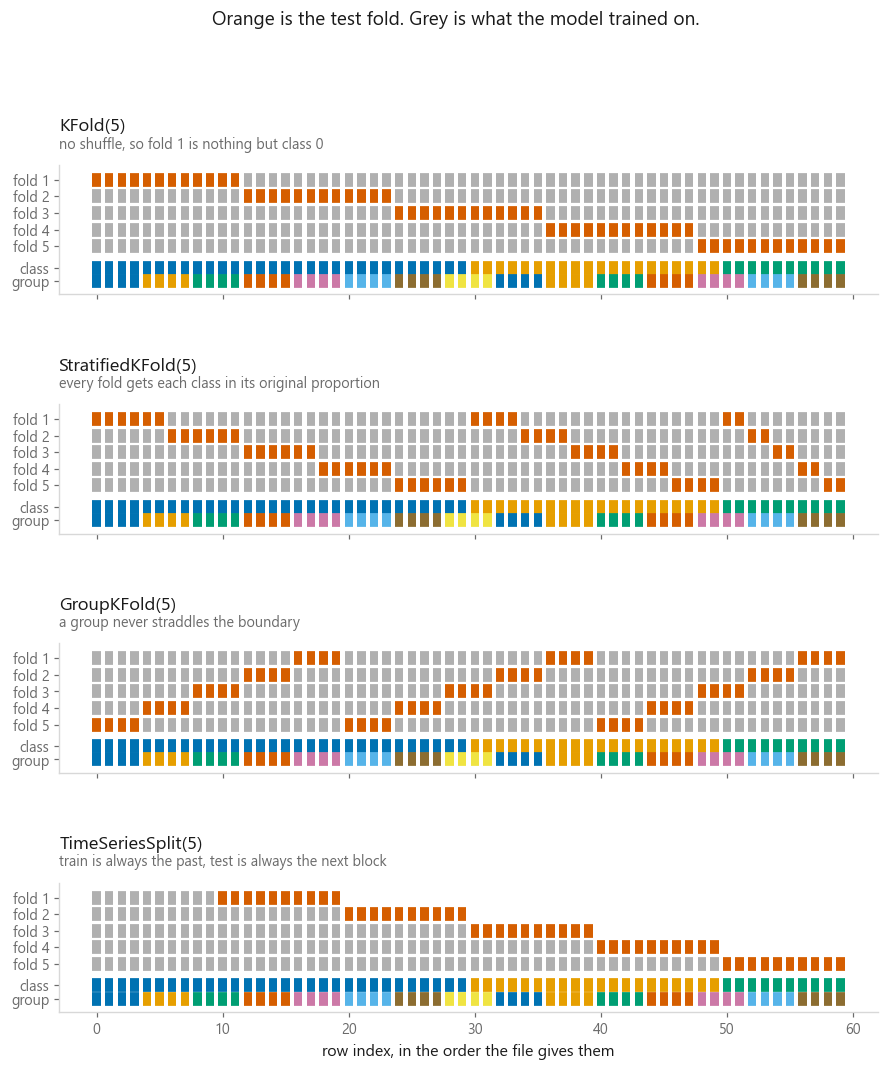

In [6]:
from sklearn.model_selection import GroupKFold, TimeSeriesSplit

n_toy = 60
toy_X = np.zeros((n_toy, 1))
toy_y = np.repeat([0, 1, 2], [30, 20, 10])     # sorted by class, as CSVs often are
toy_groups = np.repeat(np.arange(15), 4)       # four rows per group

splitters = [
    ("KFold(5)", KFold(5),
     "no shuffle, so fold 1 is nothing but class 0"),
    ("StratifiedKFold(5)", StratifiedKFold(5),
     "every fold gets each class in its original proportion"),
    ("GroupKFold(5)", GroupKFold(5),
     "a group never straddles the boundary"),
    ("TimeSeriesSplit(5)", TimeSeriesSplit(5),
     "train is always the past, test is always the next block"),
]

fig, axes = plt.subplots(4, 1, figsize=(9.6, 10.0), sharex=True)

for ax, (name, splitter, sub) in zip(axes, splitters):
    for i, (tr, te) in enumerate(splitter.split(toy_X, toy_y, toy_groups)):
        colours = np.full(n_toy, "", dtype=object)
        colours[tr] = style.NEUTRAL
        colours[te] = style.HIGHLIGHT
        used = colours != ""                    # TimeSeriesSplit leaves rows unused
        ax.scatter(np.arange(n_toy)[used], np.full(used.sum(), -i),
                   c=list(colours[used]), marker="_", lw=9)

    ax.scatter(np.arange(n_toy), np.full(n_toy, -5.3),
               c=[style.PALETTE[c] for c in toy_y], marker="_", lw=9)
    ax.scatter(np.arange(n_toy), np.full(n_toy, -6.1),
               c=[style.PALETTE[g % len(style.PALETTE)] for g in toy_groups],
               marker="_", lw=9)

    ax.set_yticks([0, -1, -2, -3, -4, -5.3, -6.1],
                  ["fold 1", "fold 2", "fold 3", "fold 4", "fold 5", "class", "group"])
    ax.set_ylim(-6.9, 0.9)
    ax.grid(False)
    style.title(ax, name, sub)

axes[-1].set_xlabel("row index, in the order the file gives them")
fig.subplots_adjust(hspace=0.85)
fig.suptitle("Orange is the test fold. Grey is what the model trained on.",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-what-each-splitter-does.png")

print("toy class counts:", np.bincount(toy_y))
print("toy groups      :", len(np.unique(toy_groups)), "groups of 4 rows")

### StratifiedKFold, the default for classification

Plain `KFold` cuts by position. If the file is sorted by label it hands a whole
class to one fold, and even after shuffling it lets the class proportions drift
from fold to fold, which hurts most when a class is small. `StratifiedKFold`
splits each class separately and then glues the pieces together, so every fold
mirrors the whole.

Dry Bean has that problem naturally: Bombay is the rarest of its seven varieties.
Below I count how many Bombay rows land in each of ten test folds under both
schemes.

In [7]:
counts = pd.Series(y_small).value_counts()
rare = counts.index[-1]
print(f"class counts in the 900-row slice:\n{counts.to_string()}\n")

plain = KFold(10, shuffle=True, random_state=SEED)
strat = StratifiedKFold(10, shuffle=True, random_state=SEED)

per_fold = pd.DataFrame({
    "fold": np.arange(1, 11),
    f"{rare} under KFold": [int((y_small[te] == rare).sum()) for _, te in plain.split(X_small, y_small)],
    f"{rare} under StratifiedKFold": [int((y_small[te] == rare).sum()) for _, te in strat.split(X_small, y_small)],
})
print(per_fold.to_string(index=False))

plain_scores = cross_val_score(tree, X_small, y_small, cv=plain)
strat_scores = cross_val_score(tree, X_small, y_small, cv=strat)
print(f"\nKFold           : mean {plain_scores.mean():.4f}  fold sd {plain_scores.std():.4f}")
print(f"StratifiedKFold : mean {strat_scores.mean():.4f}  fold sd {strat_scores.std():.4f}")

class counts in the 900-row slice:
DERMASON    234
SIRA        174
SEKER       134
HOROZ       128
CALI        108
BARBUNYA     87
BOMBAY       35

 fold  BOMBAY under KFold  BOMBAY under StratifiedKFold
    1                   3                             3
    2                   7                             3
    3                   2                             3
    4                   3                             3
    5                   2                             3
    6                   5                             4
    7                   3                             4
    8                   3                             4
    9                   6                             4
   10                   1                             4

KFold           : mean 0.8822  fold sd 0.0239
StratifiedKFold : mean 0.8778  fold sd 0.0492


The counts column is the thing to look at. Stratification pins the rare class to
nearly the same count in every fold; plain shuffling lets it drift, and a fold
holding very few examples of a class gives a per-class recall computed from
almost nothing.

For classification, use `StratifiedKFold` unless you have a reason not to.
`cross_val_score` already does this for you when you pass an integer `cv` and a
classifier, which is a sensible default that hides a decision worth knowing about.

### GroupKFold, when rows are not independent

Cross-validation assumes a test row is genuinely new. It is not new if a near-copy
of it sat in the training set. Repeated measurements of the same patient, several
frames from one video, several hours from one day — all of these break the
assumption, and random splitting sprays them across the boundary.

Bike Sharing is hourly, so 24 rows describe one day, sharing weather and the
day's overall level of demand. The file is chronological and `hr` resets each
day, so I can rebuild the day index from the row order.

### TimeSeriesSplit, when order matters

A second and separate problem: if you will deploy the model to predict the
future, training on the future is cheating even when the rows are independent.
`TimeSeriesSplit` only ever trains on rows that come before the test block.

Below, the same k-nearest-neighbours model scored three ways. I picked k-NN on
purpose because it predicts by looking up close neighbours, so it is the model
that gains most from having a near-duplicate row available.

17379 rows, 730 days, 23.8 rows per day on average


   KFold, shuffled : mean R² 0.6441   folds [0.639 0.644 0.658 0.640 0.640]
 GroupKFold by day : mean R² 0.6029   folds [0.609 0.616 0.594 0.604 0.592]
   TimeSeriesSplit : mean R² 0.2353   folds [0.115 0.265 0.020 0.312 0.464]


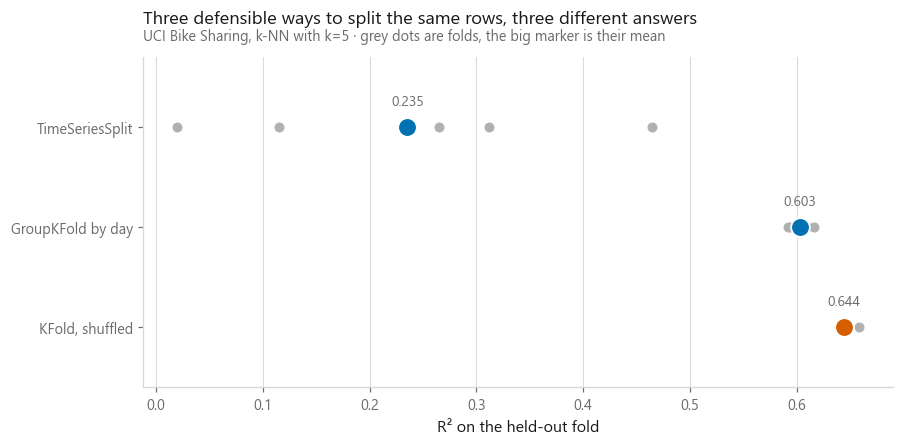

In [8]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_bike, y_bike = datasets.bike_sharing()
hours = X_bike["hr"].to_numpy()
day = np.cumsum(np.r_[True, hours[1:] <= hours[:-1]]) - 1   # new day when hr stops rising

X_bike_np, y_bike_np = X_bike.to_numpy(), y_bike.to_numpy()
print(f"{len(y_bike_np)} rows, {day.max() + 1} days, "
      f"{len(y_bike_np) / (day.max() + 1):.1f} rows per day on average")

knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))

schemes = {
    "KFold, shuffled": (KFold(5, shuffle=True, random_state=SEED), None),
    "GroupKFold by day": (GroupKFold(5), day),
    "TimeSeriesSplit": (TimeSeriesSplit(5), None),
}

fold_scores = {
    name: cross_val_score(knn, X_bike_np, y_bike_np, cv=cv, groups=groups, n_jobs=-1)
    for name, (cv, groups) in schemes.items()
}

fig, ax = plt.subplots(figsize=(8.8, 3.9))
for i, (name, scores) in enumerate(fold_scores.items()):
    colour = style.HIGHLIGHT if i == 0 else style.PALETTE[0]
    ax.scatter(scores, np.full(len(scores), i), s=34, color=style.NEUTRAL, zorder=2)
    ax.scatter([scores.mean()], [i], s=150, marker=style.MARKERS[0],
               color=colour, zorder=3, edgecolor="white", linewidth=1.2)
    ax.text(scores.mean(), i + 0.22, f"{scores.mean():.3f}", ha="center",
            fontsize=9, color=style.MUTED)

ax.set_yticks(range(len(fold_scores)), list(fold_scores))
ax.set_ylim(-0.6, len(fold_scores) - 0.3)
ax.set_xlabel("R² on the held-out fold")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax, "Three defensible ways to split the same rows, three different answers",
            "UCI Bike Sharing, k-NN with k=5 · grey dots are folds, the big marker is their mean")
style.save(fig, FIG / "fig-03-dependence.png")

for name, scores in fold_scores.items():
    print(f"{name:>18} : mean R² {scores.mean():.4f}   folds "
          f"{np.array2string(scores, precision=3, floatmode='fixed')}")

The three numbers describe three different questions. The shuffled split asks
"can you fill in a missing hour from a day you have already seen?". The grouped
split asks "can you handle a day you have never seen?". The time split asks
"can you handle next month?". Only one of those is the question you will face in
production, and the shuffled one is almost never it.

TimeSeriesSplit also varies a lot across its folds, and that is expected rather
than a fault: its first fold trains on a fifth of the history and its last trains
on nearly all of it, so the folds are not measuring the same model.

The rule I use: if you can name a thing that repeats across rows — a person, a
session, a day, a sensor, a store — group by it. If the model will be asked about
the future, split by time.

### LeaveOneOut, and why I rarely use it

`LeaveOneOut` is k-fold taken to $k = n$. Each model trains on $n - 1$ rows, so
the bias against the full-data model is as small as it can be. Three problems
follow, and I can measure all three on Breast Cancer.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut

X_bc, y_bc = datasets.breast_cancer()
X_bc_np, y_bc_np = X_bc.to_numpy(), y_bc.to_numpy()
logistic = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

results = {}
for name, cv in [("5-fold", StratifiedKFold(5, shuffle=True, random_state=SEED)),
                 ("10-fold", StratifiedKFold(10, shuffle=True, random_state=SEED)),
                 ("LeaveOneOut", LeaveOneOut())]:
    start = time.perf_counter()
    scores = cross_val_score(logistic, X_bc_np, y_bc_np, cv=cv, n_jobs=-1)
    results[name] = (scores, time.perf_counter() - start)

for name, (scores, elapsed) in results.items():
    print(f"{name:>12} : {len(scores):>3} fits  mean {scores.mean():.4f}  "
          f"fold sd {scores.std():.4f}  {elapsed:>5.1f} s")

print(f"\nLeaveOneOut fold scores take {len(np.unique(results['LeaveOneOut'][0]))} distinct "
      f"values: {np.unique(results['LeaveOneOut'][0])}")
print(f"cost of LeaveOneOut relative to 5-fold: "
      f"{results['LeaveOneOut'][1] / results['5-fold'][1]:.0f}x the time")

      5-fold :   5 fits  mean 0.9789  fold sd 0.0142    3.5 s
     10-fold :  10 fits  mean 0.9772  fold sd 0.0193    0.0 s
 LeaveOneOut : 569 fits  mean 0.9789  fold sd 0.1437    0.7 s

LeaveOneOut fold scores take 2 distinct values: [0. 1.]
cost of LeaveOneOut relative to 5-fold: 0x the time


The mean is close to the others, so the accuracy estimate itself is fine. The
problems are everywhere else.

It costs $n$ fits. On this small dataset that is seconds; on a hundred thousand
rows it is not a method.

Each fold score is 0 or 1, because a test set of one row is either right or
wrong. The standard deviation of those scores measures nothing about the
stability of the estimate — it is just the spread of a coin flip — so the one
thing cross-validation gives you beyond a point estimate is gone.

And it cannot be stratified, since a single-row test set has exactly one class.
Any metric needing both classes present, ROC-AUC among them, cannot be computed
per fold at all.

LeaveOneOut earns its place when $n$ is genuinely tiny, say under a hundred rows,
and you cannot afford to hold out five of them at a time. Otherwise use 10-fold.

### Repeated CV, when the answer still wobbles

Section 1 showed that a 5-fold mean still moves when you change the shuffle.
`RepeatedStratifiedKFold` runs the whole thing several times with different
shuffles and averages, which shrinks that movement at a cost of one fit per extra
fold. Here I can measure the wobble directly, because ten repeats give me ten
independent 5-fold means to look at.

In [10]:
from sklearn.model_selection import RepeatedStratifiedKFold

repeated = cross_val_score(
    tree, X_small, y_small,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED))

repeat_means = repeated.reshape(10, 5).mean(axis=1)   # one 5-fold answer per repeat

print(f"50 individual fold scores : mean {repeated.mean():.4f}  sd {repeated.std():.4f}")
print(f"10 whole-run 5-fold means : mean {repeat_means.mean():.4f}  sd {repeat_means.std():.4f}")
print(f"worst-to-best single run  : {repeat_means.min():.4f} to {repeat_means.max():.4f}")
print(f"\nspread of one 5-fold run vs the average of ten: "
      f"{repeat_means.std():.4f} vs {repeat_means.std() / np.sqrt(10):.4f}")

50 individual fold scores : mean 0.8822  sd 0.0242
10 whole-run 5-fold means : mean 0.8822  sd 0.0061
worst-to-best single run  : 0.8689 to 0.8889

spread of one 5-fold run vs the average of ten: 0.0061 vs 0.0019


The gap between the best and worst single run is the amount of accuracy you can
claim by trying seeds until you like the answer. Repeating flattens it. I reach
for repeated CV when I am comparing two models whose difference is smaller than
that gap, which is most of the time in tabular work.

### The part that actually matters: what happens inside the fold

Every flavour above is about *where* to cut. This section is about *what you are
allowed to do before cutting*, and it is where cross-validation is most often
broken.

The rule has one sentence. Anything that looks at the labels or at the
distribution of the data is part of the model, so it must be refitted on each
training fold. Scaling, imputing, encoding, feature selection, resampling,
choosing a hyperparameter — all of it goes inside a `Pipeline`, and the pipeline
goes into `cross_val_score`.

To measure the damage, I build a dataset with no signal at all: 200 rows, 1000
columns of Gaussian noise, and a coin-flip label. The honest score is 0.5 and
nothing can beat it. Then I select the columns most correlated with the label —
once using all the rows, the way it is usually done, and once inside a pipeline
so the selection only ever sees the training fold.

    k     leaky     piped   inflation
    1    0.6300    0.4950     +0.1350
    2    0.5900    0.4750     +0.1150
    5    0.6550    0.4700     +0.1850
   10    0.7400    0.5050     +0.2350
   20    0.7350    0.5500     +0.1850
   50    0.7950    0.5150     +0.2800
  100    0.8200    0.5650     +0.2550

largest inflation over chance: +0.3200 accuracy, on data containing nothing


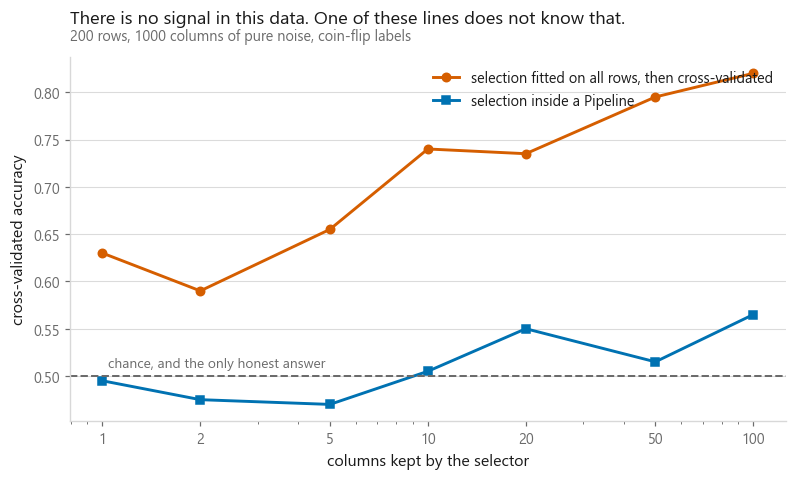

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

rng = np.random.default_rng(SEED)
n_rows, n_noise = 200, 1000
X_junk = rng.normal(size=(n_rows, n_noise))
y_junk = rng.permutation(np.repeat([0, 1], n_rows // 2))    # exactly balanced coin flips

cv_junk = StratifiedKFold(5, shuffle=True, random_state=SEED)
ks = [1, 2, 5, 10, 20, 50, 100]
leaky, honest = [], []

for k in ks:
    # The mistake: the selector sees every row, including the ones it will be tested on.
    picked = SelectKBest(f_classif, k=k).fit_transform(X_junk, y_junk)
    leaky.append(cross_val_score(LogisticRegression(max_iter=2000),
                                 picked, y_junk, cv=cv_junk).mean())

    # The fix: the selector is a step, so it is refitted on each training fold.
    honest.append(cross_val_score(
        make_pipeline(SelectKBest(f_classif, k=k), LogisticRegression(max_iter=2000)),
        X_junk, y_junk, cv=cv_junk).mean())

fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.plot(ks, leaky, marker=style.MARKERS[0], color=style.HIGHLIGHT,
        label="selection fitted on all rows, then cross-validated")
ax.plot(ks, honest, marker=style.MARKERS[1], color=style.PALETTE[0],
        label="selection inside a Pipeline")
ax.axhline(0.5, color=style.MUTED, ls="--", lw=1.3)
ax.annotate("chance, and the only honest answer", xy=(ks[0], 0.5),
            xytext=(4, 6), textcoords="offset points", fontsize=9, color=style.MUTED)
ax.set_xscale("log")
ax.set_xticks(ks, [str(k) for k in ks])
ax.set_xlabel("columns kept by the selector")
ax.set_ylabel("cross-validated accuracy")
ax.legend(loc="upper right")
style.title(ax, "There is no signal in this data. One of these lines does not know that.",
            "200 rows, 1000 columns of pure noise, coin-flip labels")
style.save(fig, FIG / "fig-04-leakage.png")

print(f"{'k':>5} {'leaky':>9} {'piped':>9} {'inflation':>11}")
for k, a, b in zip(ks, leaky, honest):
    print(f"{k:>5} {a:>9.4f} {b:>9.4f} {a - b:>+11.4f}")
print(f"\nlargest inflation over chance: "
      f"{max(np.array(leaky) - 0.5):+.4f} accuracy, on data containing nothing")

The orange line is a paper that would pass review. The selector looked at all
200 labels, kept the columns that happened to correlate with them, and then the
cross-validation loop dutifully tested on rows the selector had already read.
Every fold's "held-out" data had contributed to the choice of columns.

The blue line does the same work with the selector inside the pipeline and lands
where it should. How the gap changes as the selector keeps more columns is worth
reading off the chart yourself; what does not change is the cause, which is that
the columns were chosen with the test labels in view.

Not every leak is this expensive. A `StandardScaler` also sees the test rows if
you fit it once up front, but what leaks is a mean and a standard deviation
pooled over hundreds of rows, and no single test row moves them much.

In [12]:
scaled_once = StandardScaler().fit_transform(X_bc_np)      # the leaky version
cv_bc = StratifiedKFold(5, shuffle=True, random_state=SEED)

leaky_scaler = cross_val_score(LogisticRegression(max_iter=5000),
                               scaled_once, y_bc_np, cv=cv_bc).mean()
piped_scaler = cross_val_score(logistic, X_bc_np, y_bc_np, cv=cv_bc).mean()

print(f"scaler fitted on everything : {leaky_scaler:.4f}")
print(f"scaler inside the pipeline  : {piped_scaler:.4f}")
print(f"difference                  : {leaky_scaler - piped_scaler:+.4f}")
print(f"\nfor comparison, the feature-selection leak at k=10 was "
      f"{leaky[ks.index(10)] - honest[ks.index(10)]:+.4f}")

scaler fitted on everything : 0.9789
scaler inside the pipeline  : 0.9789
difference                  : +0.0000

for comparison, the feature-selection leak at k=10 was +0.2350


Compare the two differences printed above. Both are leaks, and both should be
fixed, because writing `Pipeline` costs nothing and you do not want to be the
person deciding case by case which leaks are small enough to keep. But knowing
which leaks are expensive tells you where to look first when a result seems too
good.

### Hyperparameters leak too

Picking the setting with the best cross-validated score, then reporting that
score, is the same mistake wearing a different hat. The number you report is a
maximum over a grid of noisy estimates, and the maximum of noisy numbers sits
above their true values. Nested cross-validation fixes it: an inner loop chooses
the hyperparameter, an outer loop scores the whole choosing-and-fitting procedure
on rows the inner loop never saw.

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

X_tune, _, y_tune, _ = train_test_split(
    X_bc_np, y_bc_np, train_size=150, stratify=y_bc_np, random_state=SEED)

grid = {"svc__C": [0.01, 0.1, 1, 10, 100, 1000],
        "svc__gamma": ["scale", 0.001, 0.01, 0.1]}
pipe = make_pipeline(StandardScaler(), SVC())

inner = StratifiedKFold(5, shuffle=True, random_state=SEED)
outer = StratifiedKFold(5, shuffle=True, random_state=SEED + 1)

search = GridSearchCV(pipe, grid, cv=inner, n_jobs=-1).fit(X_tune, y_tune)
nested = cross_val_score(GridSearchCV(pipe, grid, cv=inner, n_jobs=1),
                         X_tune, y_tune, cv=outer, n_jobs=-1)

all_grid_scores = search.cv_results_["mean_test_score"]
print(f"best setting found     : {search.best_params_}")
print(f"its CV score, reported : {search.best_score_:.4f}   <- the maximum of "
      f"{len(all_grid_scores)} noisy numbers")
print(f"nested CV score        : {nested.mean():.4f}   (folds "
      f"{np.array2string(nested, precision=3, floatmode='fixed')})")
print(f"difference             : {search.best_score_ - nested.mean():+.4f}")
print(f"\nspread across the grid : {all_grid_scores.min():.4f} to "
      f"{all_grid_scores.max():.4f}")

best setting found     : {'svc__C': 100, 'svc__gamma': 0.001}
its CV score, reported : 0.9800   <- the maximum of 24 noisy numbers
nested CV score        : 0.9667   (folds [0.967 0.967 1.000 0.967 0.933])
difference             : +0.0133

spread across the grid : 0.6267 to 0.9800


Whether the gap in one run comes out large, small, or backwards, the direction is
a property of taking a maximum, and it grows with the size of the grid. A search
over four settings barely moves it; a search over four hundred moves it a lot.

I do not run nested CV every time — it costs inner times outer fits. I use it when
I need to report a number to someone else, and I use plain `GridSearchCV` when I
only need to choose a setting and will measure the winner on a held-out test set
later.

## 5. When it wins, when it loses

Cross-validation wins whenever data is scarce enough that a single held-out set
would be small, which is nearly all tabular work. It turns one noisy number into
an average plus a sense of its spread, and it uses every row for both roles.

It loses in four situations, and three of them are avoidable.

It loses when fits are expensive. Cross-validating a network that trains for six
hours is not a decision about statistics. There you keep a fixed validation set
and accept the noise.

It loses when the folds are drawn wrong. A random split over grouped or ordered
data reports a model that does not exist, as the Bike Sharing comparison above
shows, and the failure is silent: nothing raises an error and the number that
comes back looks reasonable.

It loses when preprocessing sits outside the loop, where it manufactures skill
out of nothing, as the noise matrix shows.

And it loses when you look at it too many times. Choosing among fifty models by
cross-validated score makes the winner's score optimistic for exactly the reason
nested CV exists. A test set you touch once is still the only thing that settles
an argument. Cross-validation is how you develop; the test set is how you report.

## Cheat sheet

| Situation | Splitter |
|---|---|
| Regression, rows independent | `KFold(5 or 10, shuffle=True, random_state=...)` |
| Classification | `StratifiedKFold` — always, and especially with a rare class |
| Repeated measurements: patients, sessions, days, devices | `GroupKFold` or `StratifiedGroupKFold`, grouped by the repeating thing |
| Anything you will run on future data | `TimeSeriesSplit`, or a fixed cut by date |
| Under about 100 rows | `LeaveOneOut`, accepting that fold scores tell you nothing |
| Two models separated by less than the fold noise | `RepeatedStratifiedKFold` |
| Reporting a tuned model's score to someone | Nested CV, or a test set held back from the start |
| Any preprocessing at all | `Pipeline`, every time, no exceptions |

## What to remember

1. One train/test split is a sample of size one. Cross-validation replaces it
   with $k$ samples and their average.
2. Five or ten folds. Below five the training sets get small; above ten you pay
   for accuracy you cannot use.
3. The $k$ fold scores are correlated, so $\mathrm{sd}/\sqrt{k}$ is not a valid
   standard error. Treat the spread as a smell test.
4. Stratify for classification. Group when rows repeat. Respect order when order
   exists. Getting this wrong raises the score, which is why it survives review.
5. `LeaveOneOut` costs $n$ fits and gives fold scores of 0 and 1, which carry no
   information about stability.
6. Repeated CV is the cheapest way to stop a seed from deciding which model wins.
7. Every fit, transform, selection and hyperparameter choice belongs inside the
   fold. `Pipeline` is how you enforce it, and the noise experiment above is what
   it costs when you do not.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [01-05 Metrics for classification](../05-classification-metrics/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#CrossValidation` `#ModelEvaluation` `#DataLeakage`
`#ScikitLearn` `#Pipeline` `#Python` `#DataScience` `#MLTutorial` `#KFold`